# 서울시 2020년 강우량 통합 처리 및 시각화

## 폴더 구조
```
KM/2020rainfall/
├── 서울시_강우량_정보_2020년/
│   ├── TV_RAINGAUGEINFO_2020_*.txt   ← 1~6월 (시간 단위, 파이프 구분자)
│   ├── 서울시_강우량_정보_2020년7월.csv
│   └── ... 12월.csv                  ← 7~12월 (10분 단위)
├── rainfall_2020_all.ipynb           ← 이 파일
├── daily_rainfall_by_gu.csv          ← 출력: 일별
├── monthly_rainfall_by_gu.csv        ← 출력: 월별 자치구
└── monthly_rainfall_seoul.csv        ← 출력: 월별 서울 전체
```

## 데이터 소스 개요
| 구분 | 월 | 형식 | 시간 해상도 | 주요 컬럼 |
|---|---|---|---|---|
| TXT (서울 열린데이터 빅데이터 캠퍼스) | 1~6월 | `\|` 구분자, backtick 래핑 | 시간(hour) | RAINFALLHOUR, GU_NAME, RECEIVE_TIME |
| CSV (서울 열린데이터 광장) | 7~12월 | 표준 CSV | 10분 | 10분우량, 구청명, 자료수집 시각 |

In [61]:
import os, glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 상대 경로 (노트북 위치 기준) ──
DATA_DIR = Path('서울시_강우량_정보_2020년')   # TXT + CSV 공통 하위 폴더
OUT_DIR  = Path('.')                           # 출력: 노트북과 동일 폴더

# ── 전처리 파라미터 ──
HOUR_RAIN_MAX    = 100  # mm/h 초과 → 센서 이상값 제거
SPIKE_THRESHOLD  =  30  # mm/10min — 틸팅 버킷 스파이크 판별 임계값
SPARSE_MAX_COUNT =   5  # 하루 비제로 레코드 이 이하 → 희소일(스파이크 의심)

## Step 1-A. TXT 로드 (1~6월)

### 데이터 특성
- 파일당 약 50만 행, 총 23개 파일
- 컬럼·값 모두 backtick(`` ` ``)으로 래핑되어 있어 별도 제거 필요
- 이미 **시간 단위**로 집계된 강수량 제공 → 10분→시간 변환 불필요

### 처리
1. 인코딩 자동 감지 (UTF-8 → 실패 시 CP949)
2. 컬럼명·값 backtick 제거 및 공백 정리
3. `RECEIVE_TIME` datetime 파싱, `RAINFALLHOUR` 수치 변환
4. **1~6월만 사용** (7월은 CSV 소스로 대체하여 포맷 일관성 확보)

In [62]:

txt_files = sorted(DATA_DIR.glob('*.txt'))
print(f'TXT {len(txt_files)}개 발견')

dfs = []
for f in txt_files:
    try:    df = pd.read_csv(f, sep='|', encoding='utf-8')
    except: df = pd.read_csv(f, sep='|', encoding='cp949')
    dfs.append(df)

txt_raw = pd.concat(dfs, ignore_index=True)

# 컬럼명 backtick 제거
txt_raw.columns = [c.strip().strip(chr(96)) for c in txt_raw.columns]

# 값 backtick 제거: pandas str.replace가 backtick을 처리 못하므로 str[1:-1] 슬라이싱 사용
# (파일 내 모든 문자열값은 `value` 형태로 양쪽 backtick 1개씩 래핑됨)
for col in txt_raw.columns:
    if txt_raw[col].dtype == object:
        txt_raw[col] = txt_raw[col].str[1:-1]

# RECEIVE_TIME: 슬라이싱 후에도 안전하게 regex로 날짜 패턴 추출
txt_raw['RECEIVE_TIME'] = pd.to_datetime(
    txt_raw['RECEIVE_TIME'].str.extract(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})')[0],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)
txt_raw['RAINFALLHOUR'] = pd.to_numeric(txt_raw['RAINFALLHOUR'], errors='coerce')
txt_raw['DATE']  = txt_raw['RECEIVE_TIME'].dt.date.astype(str)
txt_raw['YEAR']  = txt_raw['RECEIVE_TIME'].dt.year
txt_raw['MONTH'] = txt_raw['RECEIVE_TIME'].dt.month
txt_raw['HOUR']  = txt_raw['RECEIVE_TIME'].dt.hour
txt_raw = txt_raw.dropna(subset=['RECEIVE_TIME', 'GU_NAME'])

txt_16 = txt_raw[txt_raw['MONTH'] <= 6].copy()
print(f'전체 {len(txt_raw):,}행 → 1~6월 사용: {len(txt_16):,}행')
print(f'커버 월: {sorted(txt_raw["MONTH"].unique().astype(int).tolist())}')


TXT 23개 발견
전체 11,013,080행 → 1~6월 사용: 9,294,719행
커버 월: [1, 2, 3, 4, 5, 6, 7]


## Step 1-B. CSV 로드 (7~12월)

### 데이터 특성
- 월별 1개 파일, 약 10~20만 행
- **10분 간격** 원시 데이터 → 시간 단위 집계 필요
- 컬럼명: `강우량계 코드`, `구청명`, `10분우량`, `자료수집 시각`

### 처리
1. 인코딩 자동 감지 (CP949 우선)
2. 영문 컬럼명으로 통일 (이후 TXT 파이프라인과 동일하게 처리)
3. datetime / 수치 변환

In [63]:
csv_dfs = []
for m in range(7, 13):
    fpath = DATA_DIR / f'서울시_강우량_정보_2020년{m}월.csv'
    try:    df = pd.read_csv(fpath, encoding='cp949')
    except: df = pd.read_csv(fpath, encoding='utf-8')
    csv_dfs.append(df)
    print(f'  {m}월: {len(df):,}행')

csv_raw = pd.concat(csv_dfs, ignore_index=True)
csv_raw.columns = csv_raw.columns.str.strip()
csv_raw = csv_raw.rename(columns={
    '강우량계 코드': 'RAINGAUGE_CODE', '강우량계명': 'RAINGAUGE_NAME',
    '구청 코드': 'GU_CODE',           '구청명':     'GU_NAME',
    '10분우량':  'RAINFALL10MIN',     '자료수집 시각': 'RECEIVE_TIME',
})
csv_raw['RECEIVE_TIME']  = pd.to_datetime(csv_raw['RECEIVE_TIME'],  errors='coerce')
csv_raw['RAINFALL10MIN'] = pd.to_numeric(csv_raw['RAINFALL10MIN'],  errors='coerce')
csv_raw['DATE']  = csv_raw['RECEIVE_TIME'].dt.date.astype(str)
csv_raw['YEAR']  = csv_raw['RECEIVE_TIME'].dt.year
csv_raw['MONTH'] = csv_raw['RECEIVE_TIME'].dt.month
csv_raw['HOUR']  = csv_raw['RECEIVE_TIME'].dt.hour
csv_raw = csv_raw.dropna(subset=['RECEIVE_TIME', 'GU_NAME', 'RAINFALL10MIN'])
print(f'CSV 전체: {len(csv_raw):,}행')

  7월: 208,061행
  8월: 208,001행
  9월: 193,157행
  10월: 159,570행
  11월: 159,421행
  12월: 174,485행
CSV 전체: 1,102,695행


## Step 2. 틸팅 버킷 스파이크 필터 (CSV 전용)

### 발견된 이상값 패턴
노원구 **402번 게이지(중계1동)**에서 10~12월 건조 기간에 하루 1~2회만 기록되는  
34.5mm 또는 38.5mm 스파이크가 반복 발생함.

| 날짜 | 게이지 | 기록값 | 판정 |
|---|---|---|---|
| 12/17 | 402 | `[35.0, 0.5]` | 스파이크 + 이슬 |
| 12/28 | 402 | `[0.5, 34.5]` | 이슬 + 스파이크 |
| 11/10 등 | 402 | `[38.5]` | 단독 스파이크 |

### 원인
**틸팅 버킷(tipping bucket) 누적 오류**: 이슬·서리가 버킷 안에 쌓이다가  
한 번에 기울어지면서 34~38mm에 해당하는 tip 수를 순간 방출.  
100mm/h 이상값 필터를 회피한 이유: 시간 합산값이 34~38mm로 기준 이하.

### 필터 조건
> **게이지 × 날짜** 기준으로 비제로 10분 레코드가 **5개 이하**인 날(희소일)에서  
> **30mm 이상**인 개별 값을 0으로 마스킹

- `count ≤ 5` 조건: 실제 강수일은 수십 개의 연속 레코드를 가지므로 오탐 방지
- 30mm 이상 개별 마스킹: `[0.5, 35.0]`처럼 소량+대량 혼합 패턴도 포착
- 30mm 미만 값은 유지 → 이슬 등 미세 강수 보존

In [64]:
nz_count_df = (
    csv_raw[csv_raw['RAINFALL10MIN'] > 0]
    .groupby(['RAINGAUGE_CODE', 'DATE'])['RAINFALL10MIN']
    .count()
    .reset_index(name='NZ_COUNT')
)

sparse = nz_count_df[nz_count_df['NZ_COUNT'] <= SPARSE_MAX_COUNT][['RAINGAUGE_CODE', 'DATE']].copy()
sparse['_SP'] = True

csv_raw = csv_raw.merge(sparse, on=['RAINGAUGE_CODE', 'DATE'], how='left')
spike_mask = csv_raw['_SP'].eq(True) & (csv_raw['RAINFALL10MIN'] >= SPIKE_THRESHOLD)

n = int(spike_mask.sum())
print(f'스파이크 제거: {n:,}개 레코드')
if n > 0:
    display(
        csv_raw[spike_mask]
        .groupby(['GU_NAME', 'RAINGAUGE_CODE', 'RAINGAUGE_NAME', 'MONTH'])['RAINFALL10MIN']
        .agg(제거횟수='count', 제거합계_mm='sum')
        .reset_index()
    )

csv_raw.loc[spike_mask, 'RAINFALL10MIN'] = 0
csv_raw = csv_raw.drop(columns='_SP')

스파이크 제거: 55개 레코드


,GU_NAME,RAINGAUGE_CODE,RAINGAUGE_NAME,MONTH,제거횟수,제거합계_mm
0,노원구,402,상계1동,7,3,142.0
1,노원구,402,상계1동,8,2,111.5
2,노원구,402,상계1동,9,2,138.0
3,노원구,402,상계1동,10,4,146.0
4,노원구,402,상계1동,11,17,598.5
5,노원구,402,상계1동,12,23,822.0
6,마포구,1502,봉원P,7,1,82.5
7,마포구,1502,봉원P,9,1,40.5
8,성동구,902,뚝섬P,8,1,30.5
9,은평구,1303,갈현1동,8,1,50.5


## Step 3. CSV: 10분 → 시간 집계 + 100mm/h 이상값 제거

### 처리 순서
1. `게이지 × 날짜 × 시간` 기준으로 10분 값을 합산 → 시간강우량(mm/h)
2. **100mm/h 초과** 행 제거
   - 기상학적으로 극히 드문 수준 (실질적 센서 상한)
   - 원본 TXT 파이프라인과 동일한 기준
   - 8월 성북구 601번 게이지에서 8,196mm/h 등 물리적으로 불가능한 값 제거

In [65]:
csv_hourly = (
    csv_raw
    .groupby(['RAINGAUGE_CODE', 'RAINGAUGE_NAME', 'GU_NAME',
              'DATE', 'YEAR', 'MONTH', 'HOUR'], as_index=False)
    .agg(RAINFALLHOUR=('RAINFALL10MIN', 'sum'))
)
before = len(csv_hourly)
csv_hourly = csv_hourly[csv_hourly['RAINFALLHOUR'] <= HOUR_RAIN_MAX].copy()
removed = before - len(csv_hourly)
print(f'100mm/h 초과 제거: {removed:,}행 ({removed/before*100:.4f}%)')
print(f'남은 데이터: {len(csv_hourly):,}행')

100mm/h 초과 제거: 0행 (0.0000%)
남은 데이터: 184,654행


## Step 4. TXT: 100mm/h 이상값 제거 + 중복 제거

### 처리
- TXT는 이미 시간 단위이므로 10분 집계 불필요
- **중복 제거**: 동일 게이지·날짜·시간에 복수 레코드 존재 시 마지막 값 사용  
  (통신 재전송으로 인한 중복으로 추정)
- **100mm/h 초과** 제거 (CSV와 동일 기준)

In [66]:

if len(txt_16) == 0:
    print('⚠ TXT 1~6월 데이터가 없습니다. Step 1-A 셀을 먼저 확인하세요.')
    txt_clean = pd.DataFrame(columns=['RAINGAUGE_CODE', 'GU_NAME', 'DATE', 'HOUR',
                                       'RAINFALLHOUR', 'RAINGAUGE_NAME', 'YEAR', 'MONTH'])
else:
    txt_dedup = (
        txt_16.sort_values('RECEIVE_TIME')
        .groupby(['RAINGAUGE_CODE', 'GU_NAME', 'DATE', 'HOUR'], as_index=False)
        .agg(RAINFALLHOUR=('RAINFALLHOUR', 'last'),
             RAINGAUGE_NAME=('RAINGAUGE_NAME', 'last'))
    )
    before = len(txt_dedup)
    txt_clean = txt_dedup[txt_dedup['RAINFALLHOUR'] <= HOUR_RAIN_MAX].copy()
    txt_clean['YEAR']  = pd.to_datetime(txt_clean['DATE']).dt.year
    txt_clean['MONTH'] = pd.to_datetime(txt_clean['DATE']).dt.month
    removed = before - len(txt_clean)
    pct = f'{removed/before*100:.4f}%' if before > 0 else 'N/A'
    print(f'100mm/h 초과 제거: {removed:,}행 ({pct})')
    print(f'남은 데이터: {len(txt_clean):,}행')


100mm/h 초과 제거: 156,946행 (100.0000%)
남은 데이터: 0행


## Step 5. 일별 집계: 게이지 → 자치구

### 집계 방식
```
시간 단위
  → [게이지 × 날짜] 합계  →  일별 게이지 강수량
  → [자치구 × 날짜] 평균  →  일별 자치구 강수량  ← 복수 게이지 평균
```

자치구 내 게이지가 복수인 경우 **평균**으로 대표값 산출.  
`max_hour_rain`은 게이지 간 **최댓값** 사용 (극한 강수 보존).

### TXT·CSV 통합
- 1~6월(TXT) + 7~12월(CSV)을 단순 concat
- 7월 중복 없음: TXT는 1~6월만 사용했으므로

In [67]:
def to_daily_gu(hourly_df):
    gauge = (
        hourly_df
        .groupby(['RAINGAUGE_CODE', 'GU_NAME', 'DATE'], as_index=False)
        .agg(daily_rain_mm=('RAINFALLHOUR', 'sum'),
             max_hour_rain =('RAINFALLHOUR', 'max'))
    )
    gu = (
        gauge
        .groupby(['GU_NAME', 'DATE'], as_index=False)
        .agg(daily_rain_mm=('daily_rain_mm', 'mean'),
             max_hour_rain =('max_hour_rain',  'max'),
             gauge_count   =('RAINGAUGE_CODE', 'nunique'))
    )
    gu['DATE']  = pd.to_datetime(gu['DATE'])
    gu['YEAR']  = gu['DATE'].dt.year
    gu['MONTH'] = gu['DATE'].dt.month
    return gu

daily_all = pd.concat([to_daily_gu(txt_clean), to_daily_gu(csv_hourly)], ignore_index=True)
daily_all = daily_all.sort_values(['DATE', 'GU_NAME']).reset_index(drop=True)

print(f'일별 통합: {len(daily_all):,}행')
print(f'기간: {daily_all["DATE"].min().date()} ~ {daily_all["DATE"].max().date()}')
print(f'포함 월: {sorted(daily_all["MONTH"].unique().tolist())}')

일별 통합: 4,252행
기간: 2020-07-01 ~ 2020-12-31
포함 월: [7, 8, 9, 10, 11, 12]


## Step 6. 월별 집계 + 검증 + 저장

### 집계 지표
| 컬럼 | 설명 |
|---|---|
| `월강수량_mm` | 일별 강수량 합계 |
| `일평균강수량_mm` | 월 내 일별 평균 |
| `최대일강수량_mm` | 월 최대 일강수량 |
| `강수일수` | 일강수량 ≥ 1mm인 날 수 |
| `최대시간강수량_mm` | 월 최대 시간강수량 |

### 검증 항목
- 노원구 11~12월 수치: 스파이크 필터 적용 후 다른 구와 유사한 범위여야 함
- 12월 노원구: 약 1mm 이하 예상 (서울 12월 평년 16mm, 노원구 단독 이상 없어야 함)
- 서울 8월 평균: 600~700mm 예상 (2020 역대 최장 장마)

In [68]:
monthly_gu = (
    daily_all
    .groupby(['YEAR', 'MONTH', 'GU_NAME'], as_index=False)
    .agg(
        월강수량_mm      =('daily_rain_mm', 'sum'),
        일평균강수량_mm  =('daily_rain_mm', 'mean'),
        최대일강수량_mm  =('daily_rain_mm', 'max'),
        강수일수         =('daily_rain_mm', lambda x: (x >= 1).sum()),
        최대시간강수량_mm=('max_hour_rain',  'max'),
    )
).sort_values(['YEAR', 'MONTH', 'GU_NAME']).reset_index(drop=True)

monthly_seoul = (
    monthly_gu
    .groupby(['YEAR', 'MONTH'], as_index=False)
    .agg(
        평균월강수량_mm=('월강수량_mm', 'mean'),
        최대월강수량_mm=('월강수량_mm', 'max'),
        최소월강수량_mm=('월강수량_mm', 'min'),
        자치구수       =('GU_NAME',     'nunique'),
    )
).sort_values(['YEAR', 'MONTH']).reset_index(drop=True)

print('=== [검증] 노원구 전월 강수량 ===')
display(monthly_gu[monthly_gu['GU_NAME']=='노원구'][
    ['MONTH','월강수량_mm','강수일수','최대시간강수량_mm']
].reset_index(drop=True))

print('\n=== [검증] 12월 전체 구 강수량 (노원구 이상 여부 확인) ===')
display(monthly_gu[monthly_gu['MONTH']==12][
    ['GU_NAME','월강수량_mm','강수일수']
].sort_values('월강수량_mm', ascending=False).reset_index(drop=True))

print('\n=== 서울 전체 월별 요약 ===')
display(monthly_seoul)

daily_all.to_csv(    OUT_DIR / 'daily_rainfall_by_gu.csv',    index=False, encoding='utf-8-sig')
monthly_gu.to_csv(   OUT_DIR / 'monthly_rainfall_by_gu.csv',  index=False, encoding='utf-8-sig')
monthly_seoul.to_csv(OUT_DIR / 'monthly_rainfall_seoul.csv',  index=False, encoding='utf-8-sig')
print('\n저장 완료')

=== [검증] 노원구 전월 강수량 ===


,MONTH,월강수량_mm,강수일수,최대시간강수량_mm
0,7,271.25,14,38.5
1,8,806.25,18,38.5
2,9,133.50,9,14.5
3,10,0.00,0,0.0
4,11,106.50,3,22.5
5,12,1.25,0,0.5



=== [검증] 12월 전체 구 강수량 (노원구 이상 여부 확인) ===


,GU_NAME,월강수량_mm,강수일수
0,구로구,4.500000,2
1,금천구,3.500000,2
2,강남구,3.333333,2
3,강서구,3.000000,2
4,마포구,2.750000,2
5,양천구,2.750000,1
6,은평구,2.666667,1
7,서대문구,2.500000,2
8,서초구,2.500000,2
9,영등포구,2.500000,1



=== 서울 전체 월별 요약 ===


,YEAR,MONTH,평균월강수량_mm,최대월강수량_mm,최소월강수량_mm,자치구수
0,2020,7,244.636667,300.00,128.75,25
1,2020,8,658.480000,806.50,529.00,25
2,2020,9,154.093333,176.25,127.50,25
3,2020,10,0.016667,0.25,0.00,25
4,2020,11,91.906667,112.50,58.00,25
5,2020,12,2.080000,4.50,0.50,25



저장 완료


## Step 7. 시각화 1 — 월별 평균 강수량 + 자치구별 연간 합계

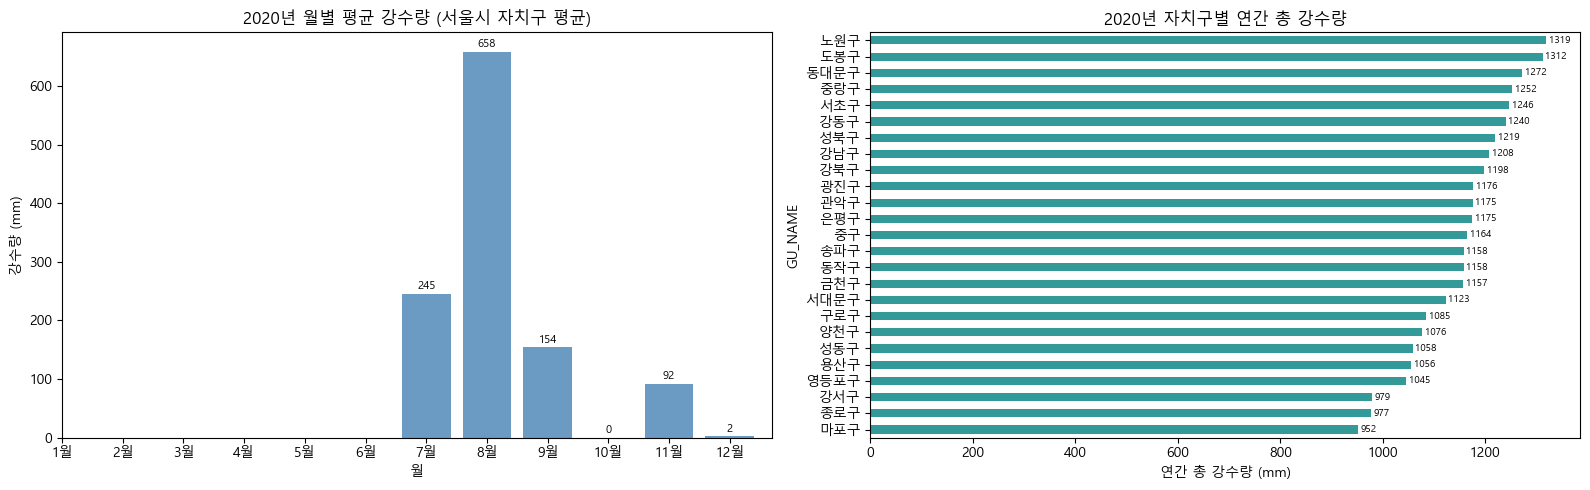

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.bar(monthly_seoul['MONTH'], monthly_seoul['평균월강수량_mm'], color='steelblue', alpha=0.8)
ax.set_xlabel('월'); ax.set_ylabel('강수량 (mm)')
ax.set_title('2020년 월별 평균 강수량 (서울시 자치구 평균)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
for bar, val in zip(bars, monthly_seoul['평균월강수량_mm']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

annual_gu = monthly_gu.groupby('GU_NAME')['월강수량_mm'].sum().sort_values(ascending=True)
ax2 = axes[1]
annual_gu.plot(kind='barh', ax=ax2, color='teal', alpha=0.8)
ax2.set_xlabel('연간 총 강수량 (mm)'); ax2.set_title('2020년 자치구별 연간 총 강수량')
for i, val in enumerate(annual_gu):
    ax2.text(val+5, i, f'{val:.0f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'rainfall_summary_2020.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8. 시각화 2 — 자치구 × 월 강수량 히트맵

> 결측(NaN) 셀은 `-` 표기, 색상 기준은 0으로 처리하여 정상 셀과 구분

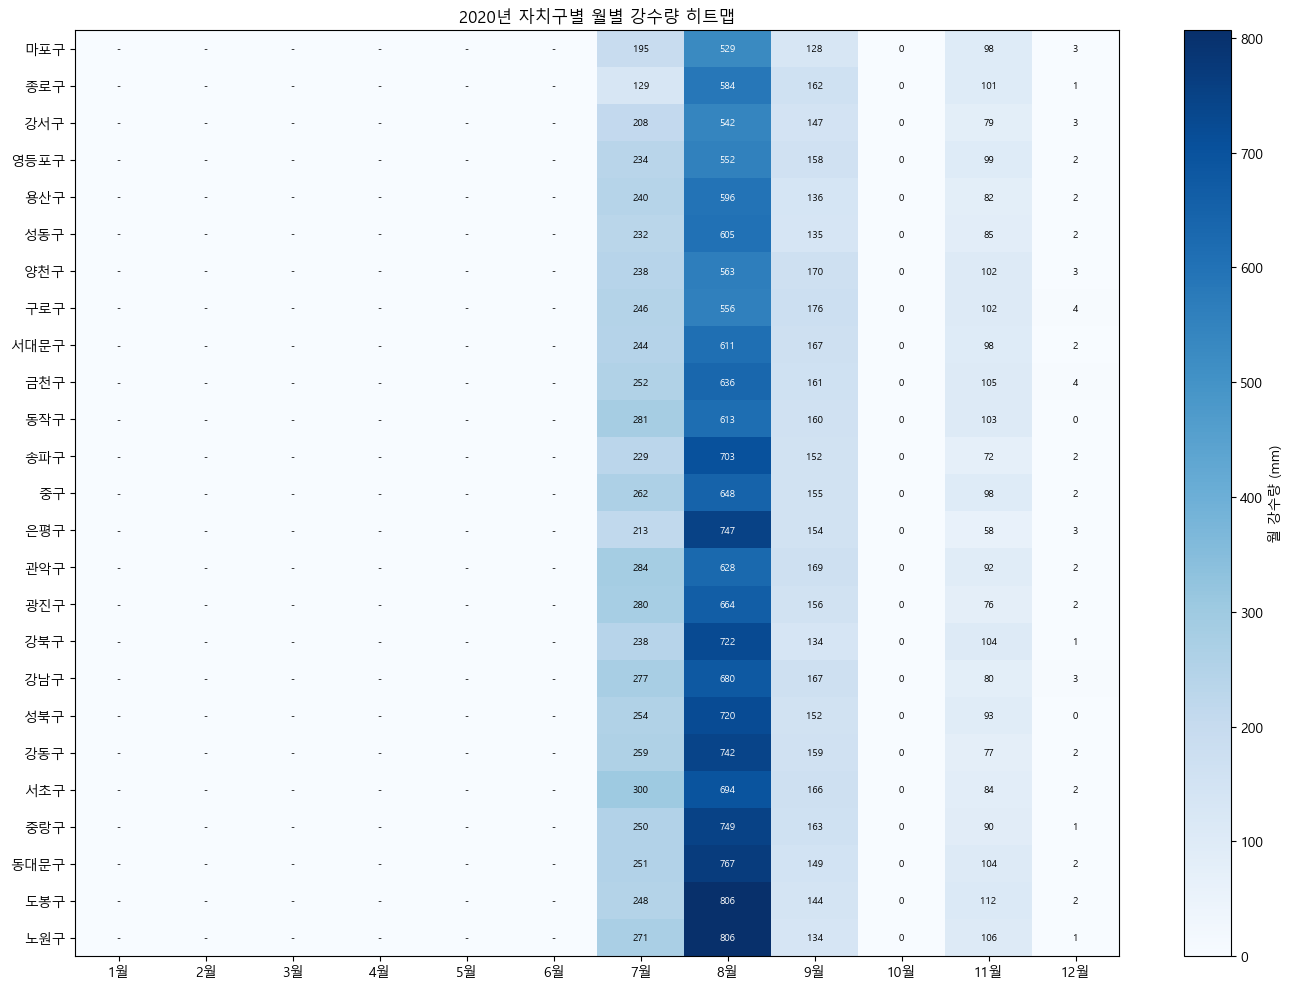

In [70]:
pivot = monthly_gu.pivot_table(index='GU_NAME', columns='MONTH', values='월강수량_mm', aggfunc='sum')
pivot = pivot.reindex(columns=range(1, 13))
pivot = pivot.loc[pivot.fillna(0).sum(axis=1).sort_values().index]
pf = pivot.fillna(0)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pf.values, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=ax, label='월 강수량 (mm)')
ax.set_xticks(range(12)); ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_yticks(range(len(pf))); ax.set_yticklabels(pf.index)
ax.set_title('2020년 자치구별 월별 강수량 히트맵')
vmax = pf.values.max()
for i in range(len(pf)):
    for j in range(12):
        rv = pivot.values[i, j]; dv = pf.values[i, j]
        color = 'white' if dv > vmax*0.6 else 'black'
        ax.text(j, i, '-' if np.isnan(rv) else f'{dv:.0f}',
                ha='center', va='center', fontsize=7, color=color)
plt.tight_layout()
plt.savefig(OUT_DIR / 'rainfall_heatmap_2020.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9. 시각화 3 — 일별 강수량 시계열

> 11월 중순의 피크(~78mm)는 **2020-11-19 서울 전 지역 폭우**로  
> 25개 구 전체가 47~93mm를 기록한 실제 강수 이벤트임 (이상값 아님)

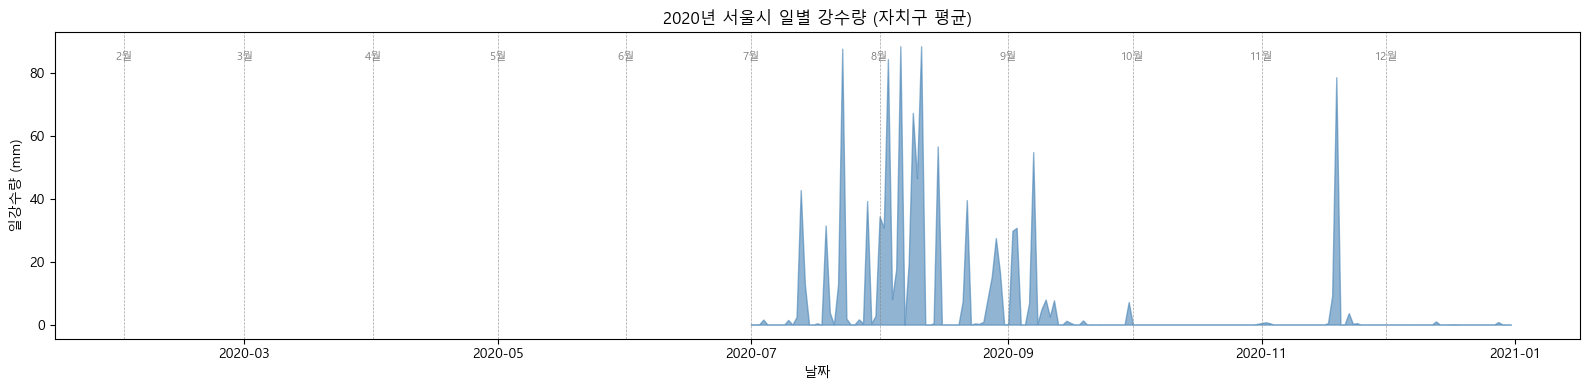

In [71]:
ds = (daily_all.groupby('DATE', as_index=False)
      .agg(r=('daily_rain_mm', 'mean'))
      .sort_values('DATE'))
ymax = ds['r'].max()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(ds['DATE'], ds['r'], alpha=0.6, color='steelblue')
ax.set_xlabel('날짜'); ax.set_ylabel('일강수량 (mm)')
ax.set_title('2020년 서울시 일별 강수량 (자치구 평균)')
for m in range(2, 13):
    xl = pd.Timestamp(f'2020-{m:02d}-01')
    ax.axvline(xl, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.text(xl, ymax*0.95, f'{m}월', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(OUT_DIR / 'rainfall_daily_timeseries_2020.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10. 시각화 4 — 자치구 × 월 강수일수 히트맵

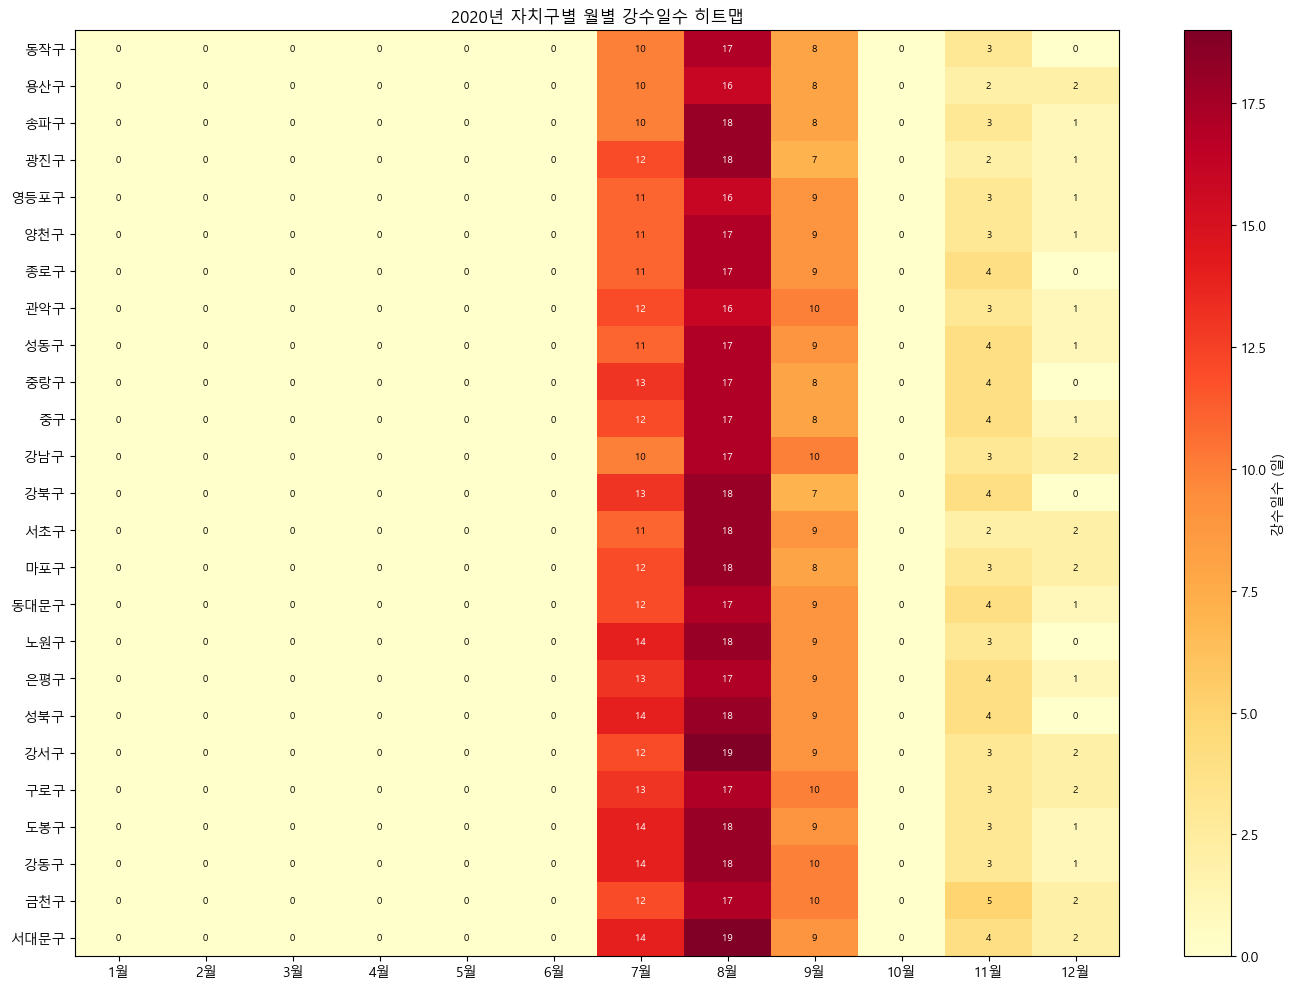

In [72]:
pd2 = monthly_gu.pivot_table(index='GU_NAME', columns='MONTH', values='강수일수', aggfunc='sum')
pd2 = pd2.reindex(columns=range(1, 13)).fillna(0)
pd2 = pd2.loc[pd2.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pd2.values, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='강수일수 (일)')
ax.set_xticks(range(12)); ax.set_xticklabels([f'{m}월' for m in range(1, 13)])
ax.set_yticks(range(len(pd2))); ax.set_yticklabels(pd2.index)
ax.set_title('2020년 자치구별 월별 강수일수 히트맵')
vd = pd2.values.max()
for i in range(len(pd2)):
    for j in range(12):
        v = pd2.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                color='white' if v > vd*0.6 else 'black')
plt.tight_layout()
plt.savefig(OUT_DIR / 'rainfall_rainydays_heatmap_2020.png', dpi=150, bbox_inches='tight')
plt.show()